# Giai đoạn 3: Tiền xử lý dữ liệu & Kỹ nghệ đặc trưng (Data Preprocessing & Feature Engineering)

Mục tiêu của giai đoạn này là chuẩn bị một tập dữ liệu sạch, liên tục và giàu thông tin (nhiều đặc trưng hữu ích) từ dữ liệu thời tiết thô để sẵn sàng đưa vào các mô hình Machine Learning và Deep Learning.
Dữ liệu thô gồm các thông số khí tượng theo giờ thu thập từ 3 trạm thời tiết (Hà Nội, Đà Nẵng, TP.HCM) trong 10 năm qua.

### Ý nghĩa của các thông số khí tượng ban đầu:
- **`temp` (Nhiệt độ - °C):** Cho biết mức độ nóng lạnh của không khí.
- **`rhum` (Độ ẩm - %):** Độ ẩm tương đối của không khí.
- **`prcp` (Lượng mưa - mm):** Lượng nước mưa tích lũy trong 1 giờ.
- **`wspd` (Tốc độ gió - km/h):** Tốc độ di chuyển của luồng gió.
- **`wdir` (Hướng gió - độ):** Hướng gió thổi (từ 0 đến 360 độ, ví dụ 360/0 độ là hướng Bắc, 90 độ là hướng Đông, 180 độ là hướng Nam, 270 độ là hướng Tây).
- **`pres` (Áp suất khí quyển - hPa):** Áp lực của cột không khí.
- **`cldc` (Mây che phủ - %):** Tỷ lệ bầu trời bị mây bao phủ.
- **`coco` (Mã thời tiết):** Chỉ số phân loại trạng thái thời tiết (ví dụ: 1 là trời quang, 8 là mưa to, v.v.).

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị tiếng Việt trên biểu đồ và cấu hình đồ họa
plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

/Users/quangnguyentamhuu/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Tải dữ liệu từ Cơ sở dữ liệu SQLite
Chúng sẽ đọc bảng `hourly_weather` chứa dữ liệu thời tiết thô của 3 thành phố từ file `../data/database/weather_data.db`.

In [2]:
# Kết nối cơ sở dữ liệu và tải dữ liệu thô
conn = sqlite3.connect("../data/database/weather_data.db")
truy_van = "SELECT * FROM hourly_weather"
df_tho = pd.read_sql_query(truy_van, conn)
conn.close()

print(f"Kích thước dữ liệu thời tiết thô: {df_tho.shape} (Dòng, Cột)")
print("\n3 dòng đầu tiên của dữ liệu thô:")
df_tho.head(3)

Kích thước dữ liệu thời tiết thô: (273010, 15) (Dòng, Cột)

3 dòng đầu tiên của dữ liệu thô:


,city,station_id,time,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,cldc,coco
0,Ha Noi,48820,2016-01-01 00:00:00,16.0,None,82.0,NaN,None,30.0,5.4,NaN,1028.0,None,0.0,NaN
1,Ha Noi,48820,2016-01-01 01:00:00,17.0,None,77.0,NaN,None,50.0,5.4,NaN,1028.0,None,NaN,NaN
2,Ha Noi,48820,2016-01-01 02:00:00,17.0,None,77.0,NaN,None,50.0,3.6,NaN,1028.0,None,NaN,NaN


## 2. Tiền xử lý dữ liệu (Làm sạch & Điền khuyết)
Dữ liệu thực tế thường bị khuyết thiếu (NaN) do lỗi thiết bị đo hoặc đường truyền mạng. Chúng ta thực hiện các bước sau:
1. **Xử lý lượng mưa khuyết thiếu:** Nếu lượng mưa (`prcp`) hoặc lượng tuyết (`snow`) bị trống (NaN), điều đó có nghĩa là thời điểm đó trời không mưa/không tuyết. Chúng ta sẽ điền giá trị `0` (0 mm).
2. **Xử lý cột khuyết thiếu nặng (>50%):** Các cột điểm sương (`dwpt`), lượng tuyết (`snow`), gió giật (`wpgt`), và thời gian nắng (`tsun`) hầu như trống hoàn toàn tại Việt Nam nên sẽ bị loại bỏ để giảm nhiễu.
3. **Đảm bảo tính liên tục của chuỗi thời gian:** Thời gian trong dữ liệu chuỗi thời gian phải liên tục từng giờ (không bị nhảy cóc). Ta sẽ phát hiện các mốc giờ bị thiếu, chèn dòng trống vào, sau đó dùng phương pháp **Nội suy tuyến tính (Linear Interpolation)** để điền các giá trị thời tiết khuyết thiếu dựa trên các giờ liền trước và liền sau.
4. **Nội suy theo từng thành phố:** Việc làm sạch và điền khuyết phải thực hiện riêng lẻ cho từng thành phố (`city`) để tránh hiện tượng rò rỉ dữ liệu khí hậu từ thành phố này sang thành phố khác.

In [3]:
# Chuyển đổi cột thời gian sang định dạng Datetime của Pandas
df_tho['time'] = pd.to_datetime(df_tho['time'])

# Bước 1: Điền giá trị 0 cho lượng mưa (prcp) và lượng tuyết (snow) bị trống
# NaN của lượng mưa thực chất là không mưa (0 mm)
df_tho['prcp'] = df_tho['prcp'].fillna(0)
df_tho['snow'] = df_tho['snow'].fillna(0)

# Bước 2: Tìm và loại bỏ các cột có tỷ lệ trống > 50%
ty_le_trong = df_tho.isnull().mean()
cac_cot_loai_bo = ty_le_trong[ty_le_trong > 0.5].index.tolist()
print(f"-> Các cột bị loại bỏ do thiếu hơn 50% dữ liệu: {cac_cot_loai_bo}")
df_loc = df_tho.drop(columns=cac_cot_loai_bo)

# Bước 3: Nội suy và làm sạch dữ liệu riêng cho từng thành phố
danh_sach_sach = []

for ten_thanh_pho, nhom in df_loc.groupby('city'):
    print(f"\nĐang làm sạch dữ liệu cho thành phố: {ten_thanh_pho}...")
    
    # Sắp xếp theo thứ tự thời gian tăng dần
    nhom = nhom.set_index('time').sort_index()
    
    # Tạo dải thời gian liên tục từng giờ từ mốc đầu tiên đến mốc cuối cùng
    thoi_gian_day_du = pd.date_range(start=nhom.index.min(), end=nhom.index.max(), freq='h')
    
    # Reindex để chèn các mốc giờ bị thiếu vào dữ liệu
    nhom = nhom.reindex(thoi_gian_day_du)
    
    # Điền lại tên thành phố và mã trạm bị thiếu sau khi reindex
    nhom['city'] = ten_thanh_pho
    nhom['station_id'] = nhom['station_id'].ffill().bfill()
    
    # Đảm bảo lượng mưa sau reindex vẫn bằng 0 nếu bị trống
    if 'prcp' in nhom.columns:
        nhom['prcp'] = nhom['prcp'].fillna(0)
        
    # Nội suy tuyến tính cho các thông số khí tượng liên tục còn lại
    cac_cot_noi_suy = [c for c in ['temp', 'rhum', 'wdir', 'wspd', 'pres', 'cldc'] if c in nhom.columns]
    for cot in cac_cot_noi_suy:
        nhom[cot] = nhom[cot].interpolate(method='linear').ffill().bfill()
        
    # Điền giá trị phân loại trạng thái thời tiết (coco) bằng giá trị gần nhất
    if 'coco' in nhom.columns:
        nhom['coco'] = nhom['coco'].ffill().bfill().astype(int)
        
    # Đưa index thời gian trở lại thành cột dữ liệu thường
    nhom = nhom.reset_index().rename(columns={'index': 'time'})
    danh_sach_sach.append(nhom)

# Gộp dữ liệu sạch của 3 thành phố lại thành một bảng duy nhất
df_sach = pd.concat(danh_sach_sach, ignore_index=True)
print(f"\nKích thước tập dữ liệu sau khi làm sạch & điền khuyết: {df_sach.shape}")
print(f"Tổng số giá trị trống còn lại: {df_sach.isnull().sum().sum()}")

-> Các cột bị loại bỏ do thiếu hơn 50% dữ liệu: ['dwpt', 'wpgt', 'tsun', 'cldc']


/var/folders/kp/56py7njj64scs8fdhrm5xv6h0000gn/T/ipykernel_10743/3951501383.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_tho['snow'] = df_tho['snow'].fillna(0)



Đang làm sạch dữ liệu cho thành phố: Da Nang...

Đang làm sạch dữ liệu cho thành phố: Ha Noi...

Đang làm sạch dữ liệu cho thành phố: TP HCM...

Kích thước tập dữ liệu sau khi làm sạch & điền khuyết: (273237, 11)
Tổng số giá trị trống còn lại: 227


## 3. Kỹ nghệ đặc trưng (Feature Engineering)
Để mô hình Machine Learning/Deep Learning học tốt hơn quy luật thời tiết, chúng ta tạo thêm các đặc trưng mới từ dữ liệu gốc.

### 3.1. Mã hóa chu kỳ thời gian (Cyclic Encoding)
Thời gian mang tính chu kỳ tuần hoàn (Giờ: 0-23, Tháng: 1-12). Nếu giữ nguyên số `0` và `23` dạng tuyến tính, mô hình sẽ hiểu chúng cách rất xa nhau (23 đơn vị), trong khi thực tế giờ 23 và giờ 00 chỉ cách nhau 1 tiếng.
Giải pháp là **Mã hóa Sin/Cos** để biểu diễn giờ và tháng lên vòng tròn lượng giác đơn vị:
- $X_{\sin} = \sin\left(\frac{2 \pi \cdot X}{\text{Chu kỳ}}\right)$
- $X_{\cos} = \cos\left(\frac{2 \pi \cdot X}{\text{Chu kỳ}}\right)$
- Với Giờ (Hour): Chu kỳ là 24.
- Với Tháng (Month): Chu kỳ là 12.

In [4]:
# Trích xuất giờ trong ngày (0-23) và tháng trong năm (1-12)
df_sach['hour'] = df_sach['time'].dt.hour
df_sach['month'] = df_sach['time'].dt.month

# Áp dụng công thức Sin/Cos cho Giờ (Chu kỳ 24)
df_sach['hour_sin'] = np.sin(2 * np.pi * df_sach['hour'] / 24.0)
df_sach['hour_cos'] = np.cos(2 * np.pi * df_sach['hour'] / 24.0)

# Áp dụng công thức Sin/Cos cho Tháng (Chu kỳ 12)
df_sach['month_sin'] = np.sin(2 * np.pi * df_sach['month'] / 12.0)
df_sach['month_cos'] = np.cos(2 * np.pi * df_sach['month'] / 12.0)

print("Ví dụ kết quả mã hóa chu kỳ cho thời gian:")
df_sach[['time', 'hour', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos']].head(3)

Ví dụ kết quả mã hóa chu kỳ cho thời gian:


,time,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,2016-01-01 00:00:00,0,0.000000,1.000000,1,0.5,0.866025
1,2016-01-01 01:00:00,1,0.258819,0.965926,1,0.5,0.866025
2,2016-01-01 02:00:00,2,0.500000,0.866025,1,0.5,0.866025


### 3.2. Đặc trưng trễ (Lag Features)
Thời tiết hiện tại bị ảnh hưởng rất lớn bởi thời tiết của những giờ trước (Ví dụ: 1 giờ trước đang rất nóng thì giờ hiện tại khả năng cao vẫn nóng). Các thông số trễ giúp mô hình nắm giữ trạng thái khí tượng quá khứ gần.
Ta tạo các đặc trưng trễ ở các mốc: **1 giờ trước (`_lag_1h`), 2 giờ trước (`_lag_2h`), 3 giờ trước (`_lag_3h`), 6 giờ trước (`_lag_6h`), 12 giờ trước (`_lag_12h`), và 24 giờ trước (`_lag_24h`)** cho các biến quan trọng:
* `temp` (Nhiệt độ)
* `rhum` (Độ ẩm)
* `prcp` (Lượng mưa)
* `wspd` (Tốc độ gió)

Chúng ta phải tạo đặc trưng trễ theo từng nhóm thành phố để tránh rò rỉ dữ liệu chéo giữa các tỉnh/thành.

In [5]:
cac_moc_tre = [1, 2, 3, 6, 12, 24]
bien_tre = ['temp', 'rhum', 'prcp', 'wspd']

danh_sach_tre = []

# Duyệt qua từng thành phố để tính toán giá trị trễ tránh trộn lẫn dữ liệu
for ten_thanh_pho, nhom in df_sach.groupby('city'):
    nhom_copy = nhom.copy()
    for cot in bien_tre:
        for tre in cac_moc_tre:
            # Dịch chuyển chuỗi thời gian xuống 'tre' dòng để lấy dữ liệu quá khứ
            nhom_copy[f'{cot}_lag_{tre}h'] = nhom_copy[cot].shift(tre)
    danh_sach_tre.append(nhom_copy)

# Gộp các thành phố lại thành DataFrame mới
df_tre = pd.concat(danh_sach_tre, ignore_index=True)
print(f"Đã tạo xong đặc trưng trễ. Tổng số cột hiện tại: {len(df_tre.columns)}")

Đã tạo xong đặc trưng trễ. Tổng số cột hiện tại: 41


### 3.3. Đặc trưng thống kê trượt (Rolling Features)
Đặc trưng trượt giúp mô hình học được xu hướng biến động dài hạn hơn (ví dụ: nhiệt độ trung bình ngày, độ biến động của độ ẩm trong những giờ qua).
Chúng ta tính toán hai chỉ số thống kê trong các khoảng thời gian cửa sổ trượt (6 giờ qua và 24 giờ qua) cho **Nhiệt độ (`temp`)** và **Độ ẩm (`rhum`)**:
1. **Trung bình trượt (Rolling Mean):** Cho biết xu hướng thời tiết tổng thể trong cửa sổ trượt (trời đang ấm lên hay lạnh đi).
2. **Độ lệch chuẩn trượt (Rolling Std):** Đo lường mức độ biến động/ổn định của thời tiết trong cửa sổ trượt (thời tiết biến đổi đột ngột hay ổn định).

In [6]:
danh_sach_truot = []

# Duyệt qua từng thành phố để tính toán thống kê trượt độc lập
for ten_thanh_pho, nhom in df_tre.groupby('city'):
    nhom_copy = nhom.copy().sort_values('time')
    
    # Cửa sổ trượt 6 giờ và 24 giờ cho Nhiệt độ (temp)
    nhom_copy['temp_roll_mean_6h'] = nhom_copy['temp'].rolling(window=6).mean()
    nhom_copy['temp_roll_std_6h'] = nhom_copy['temp'].rolling(window=6).std()
    nhom_copy['temp_roll_mean_24h'] = nhom_copy['temp'].rolling(window=24).mean()
    nhom_copy['temp_roll_std_24h'] = nhom_copy['temp'].rolling(window=24).std()
    
    # Cửa sổ trượt 6 giờ và 24 giờ cho Độ ẩm (rhum)
    nhom_copy['rhum_roll_mean_6h'] = nhom_copy['rhum'].rolling(window=6).mean()
    nhom_copy['rhum_roll_std_6h'] = nhom_copy['rhum'].rolling(window=6).std()
    nhom_copy['rhum_roll_mean_24h'] = nhom_copy['rhum'].rolling(window=24).mean()
    nhom_copy['rhum_roll_std_24h'] = nhom_copy['rhum'].rolling(window=24).std()
    
    danh_sach_truot.append(nhom_copy)

df_toan_bo = pd.concat(danh_sach_truot, ignore_index=True)

# Loại bỏ các dòng đầu tiên bị trống (NaN) do không đủ dữ liệu quá khứ để tính trễ/trượt
# (mốc trễ lớn nhất là 24h nên ta sẽ loại bỏ đúng 24 dòng đầu của mỗi thành phố: 24 * 3 = 72 dòng)
df_cuoi = df_toan_bo.dropna().copy()

print(f"Kích thước tập dữ liệu hoàn chỉnh sau Feature Engineering và loại bỏ dòng trống: {df_cuoi.shape}")

Kích thước tập dữ liệu hoàn chỉnh sau Feature Engineering và loại bỏ dòng trống: (272938, 49)


## 4. Phân tích tương quan đặc trưng (Correlation Heatmap)
Chúng ta vẽ bản đồ nhiệt tương quan (Heatmap) giữa Nhiệt độ hiện tại (`temp`) với các đặc trưng trễ và trượt vừa tạo.
- Hệ số tương quan gần `1.0` thể hiện mối quan hệ tỷ lệ thuận mạnh mẽ.
- Hệ số tương quan gần `-1.0` thể hiện mối quan hệ tỷ lệ nghịch mạnh mẽ.
- Hệ số tương quan gần `0` thể hiện không có mối quan hệ tuyến tính.

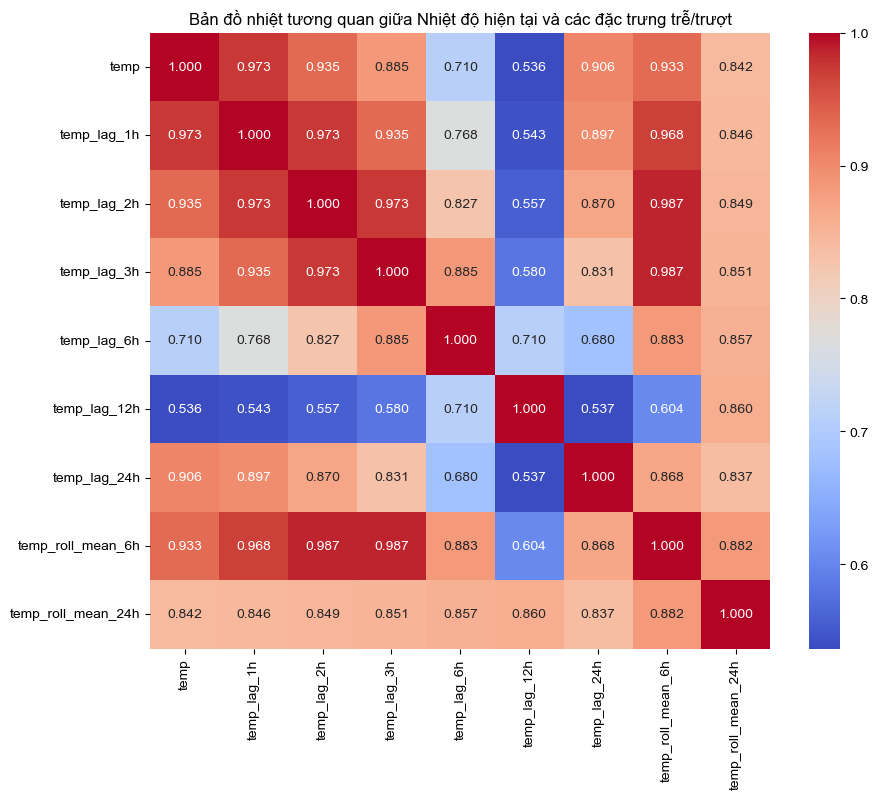

In [7]:
plt.figure(figsize=(10, 8))
cac_cot_tuong_quan = [
    'temp', 'temp_lag_1h', 'temp_lag_2h', 'temp_lag_3h', 
    'temp_lag_6h', 'temp_lag_12h', 'temp_lag_24h', 
    'temp_roll_mean_6h', 'temp_roll_mean_24h'
]

# Tính toán ma trận tương quan Pearson
ma_tran_tuong_quan = df_cuoi[cac_cot_tuong_quan].corr()

# Vẽ biểu đồ tương quan với chú thích tiếng Việt
sns.heatmap(ma_tran_tuong_quan, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Bản đồ nhiệt tương quan giữa Nhiệt độ hiện tại và các đặc trưng trễ/trượt')
plt.show()

## 5. Lưu trữ Dữ liệu đã qua Tiền xử lý vào SQLite Database
Chúng ta lưu DataFrame hoàn chỉnh chứa tất cả các đặc trưng vào bảng mới mang tên `processed_weather` trong file database `../data/database/weather_data.db`.

In [8]:
# Tạo bản sao và chuyển đổi cột time về dạng chuỗi định dạng chuẩn để lưu vào SQLite
df_luu_db = df_cuoi.copy()
df_luu_db['time'] = df_luu_db['time'].dt.strftime('%Y-%m-%d %H:%M:%S')

conn = sqlite3.connect("../data/database/weather_data.db")
print("-> Đang lưu dữ liệu đã qua tiền xử lý vào bảng 'processed_weather'...")

# Lưu dữ liệu vào DB (chèn đè nếu bảng đã tồn tại)
df_luu_db.to_sql("processed_weather", conn, if_exists="replace", index=False)

# Thiết lập index cho 2 cột station_id và time để tối ưu hóa truy vấn dữ liệu sau này
cursor = conn.cursor()
cursor.execute("CREATE INDEX IF NOT EXISTS idx_proc_weather ON processed_weather (station_id, time)")
conn.commit()

print("-> Đã lưu dữ liệu sạch thành công!")

# In thống kê số lượng dòng của mỗi thành phố
cursor.execute("SELECT city, COUNT(*) FROM processed_weather GROUP BY city")
dong_ket_qua = cursor.fetchall()
print("\nThống kê số lượng dòng sạch lưu trong database cho từng thành phố:")
for dong in dong_ket_qua:
    print(f"  Thành phố: {dong[0]:<15} | Số dòng sạch: {dong[1]}")
    
conn.close()

-> Đang lưu dữ liệu đã qua tiền xử lý vào bảng 'processed_weather'...
-> Đã lưu dữ liệu sạch thành công!

Thống kê số lượng dòng sạch lưu trong database cho từng thành phố:
  Thành phố: Da Nang         | Số dòng sạch: 90919
  Thành phố: Ha Noi          | Số dòng sạch: 91012
  Thành phố: TP HCM          | Số dòng sạch: 91007
